In [11]:
import pandas as pd

data = pd.read_csv("../../processed/cedar_predicted.csv")
print("total peptides:", len(data))
print("unique peptides", len(data["epitope_id"].unique()))
data.head()

total peptides: 6520
unique peptides 6327


,epitope_id,hla,label,mt_seq,wt_seq,mt_length,mt_affinity,mt_affinity_percentile,mt_presentation_score,mt_presentation_percentile,wt_affinity,wt_affinity_percentile,wt_presentation_score,wt_presentation_percentile,mt_presented,wt_presented,delta_affinity,delta_presentation_score
0,551,HLA-A*02:01,1,ACDPHSGHFV,ARDPHSGHFV,10,3125.736683,2.796875,0.053443,4.807092,13379.793366,7.050250,0.029345,8.269212,0,0,-10254.056683,0.024097
1,3147,HLA-A*02:01,1,AMLGTHTMEV,AMLSPHAMDV,10,37.507257,0.260250,0.768811,0.326821,104.448134,0.625750,0.483023,0.858478,1,1,-66.940877,0.285789
2,14672,HLA-A*01:01,1,EVDPIGHLY,EVVPISHLY,9,33.501012,0.007125,0.983180,0.004511,164.471650,0.231000,0.941244,0.060136,1,1,-130.970638,0.041936
3,14672,HLA-A*11:01,1,EVDPIGHLY,EVVPISHLY,9,942.095939,1.615250,0.695778,0.443832,1086.646020,1.703250,0.719056,0.406060,1,1,-144.550081,-0.023279
4,14672,HLA-B*35:01,1,EVDPIGHLY,EVVPISHLY,9,64.056180,0.173750,0.968890,0.021413,50.299185,0.111375,0.980633,0.007255,1,1,13.756994,-0.011743


In [12]:
#choose best hla for each peptide
#best is lowest mutant presentation percentile

best_idx = (data.groupby("epitope_id")["mt_presentation_percentile"].idxmin())
#keep only those rows
rollup = data.loc[best_idx].copy()

#rename
rollup = rollup.rename(columns={"hla": "best_hla"})
print("rolled up to:", len(rollup))

rolled up to: 6327


In [14]:
#define presentation status
import numpy as np
rollup["mt_presented"] = (rollup["mt_presentation_percentile"]<=2).astype(int)
rollup["wt_presented"] = (rollup["wt_presentation_percentile"]<=2).astype(int)

rollup["delta_log_affinity"] = np.log(rollup["mt_affinity"]) - np.log(rollup["wt_affinity"])

print(rollup["mt_presented"].value_counts())
print(rollup["wt_presented"].value_counts())
rollup.head()

mt_presented
1    4875
0    1452
Name: count, dtype: int64
wt_presented
1    3709
0    2618
Name: count, dtype: int64


,epitope_id,best_hla,label,mt_seq,wt_seq,mt_length,mt_affinity,mt_affinity_percentile,mt_presentation_score,mt_presentation_percentile,wt_affinity,wt_affinity_percentile,wt_presentation_score,wt_presentation_percentile,mt_presented,wt_presented,delta_affinity,delta_presentation_score,delta_log_affinity
0,551,HLA-A*02:01,1,ACDPHSGHFV,ARDPHSGHFV,10,3125.736683,2.796875,0.053443,4.807092,13379.793366,7.050250,0.029345,8.269212,0,0,-10254.056683,0.024097,-1.454076
1955,785,HLA-B*44:03,0,ADVEFCLSL,ANVEFCL,9,848.828242,0.972500,0.108789,2.760054,32406.910919,40.329625,0.004118,62.744674,0,0,-31558.082677,0.104670,-3.642270
1,3147,HLA-A*02:01,1,AMLGTHTMEV,AMLSPHAMDV,10,37.507257,0.260250,0.768811,0.326821,104.448134,0.625750,0.483023,0.858478,1,1,-66.940877,0.285789,-1.024156
2,14672,HLA-A*01:01,1,EVDPIGHLY,EVVPISHLY,9,33.501012,0.007125,0.983180,0.004511,164.471650,0.231000,0.941244,0.060136,1,1,-130.970638,0.041936,-1.591163
6,23214,HLA-A*02:01,1,GVYDGEEHSV,GAYDGEEH,10,46.603713,0.330000,0.871138,0.167038,29876.517551,41.398000,0.003482,99.286603,1,0,-29829.913838,0.867656,-6.463148


In [15]:
#log affinity change
#lower - stronger binding
rollup["delta_log_affinity"] = (np.log(rollup["mt_affinity"]) - np.log(rollup["wt_affinity"]))
rollup.head()

,epitope_id,best_hla,label,mt_seq,wt_seq,mt_length,mt_affinity,mt_affinity_percentile,mt_presentation_score,mt_presentation_percentile,wt_affinity,wt_affinity_percentile,wt_presentation_score,wt_presentation_percentile,mt_presented,wt_presented,delta_affinity,delta_presentation_score,delta_log_affinity
0,551,HLA-A*02:01,1,ACDPHSGHFV,ARDPHSGHFV,10,3125.736683,2.796875,0.053443,4.807092,13379.793366,7.050250,0.029345,8.269212,0,0,-10254.056683,0.024097,-1.454076
1955,785,HLA-B*44:03,0,ADVEFCLSL,ANVEFCL,9,848.828242,0.972500,0.108789,2.760054,32406.910919,40.329625,0.004118,62.744674,0,0,-31558.082677,0.104670,-3.642270
1,3147,HLA-A*02:01,1,AMLGTHTMEV,AMLSPHAMDV,10,37.507257,0.260250,0.768811,0.326821,104.448134,0.625750,0.483023,0.858478,1,1,-66.940877,0.285789,-1.024156
2,14672,HLA-A*01:01,1,EVDPIGHLY,EVVPISHLY,9,33.501012,0.007125,0.983180,0.004511,164.471650,0.231000,0.941244,0.060136,1,1,-130.970638,0.041936,-1.591163
6,23214,HLA-A*02:01,1,GVYDGEEHSV,GAYDGEEH,10,46.603713,0.330000,0.871138,0.167038,29876.517551,41.398000,0.003482,99.286603,1,0,-29829.913838,0.867656,-6.463148


In [16]:
#define subgroups
groups = []
for i, row in rollup.iterrows(): 
    if row["mt_presented"] == 1 and row["label"] == 1: 
        groups.append("presented_immunogenic")
    elif row["mt_presented"] == 1 and row["label"] == 0: 
        groups.append("presented_nonimmunogenic")
    elif row["mt_presented"] == 0 and row["label"] == 1: 
        groups.append("notpresented_immunogenic")
    else: 
        groups.append("notpresented_nonimmunogenic")
rollup["group"] = groups
print(rollup["group"].value_counts()) 
rollup.head()

group
presented_nonimmunogenic       3328
presented_immunogenic          1547
notpresented_nonimmunogenic    1119
notpresented_immunogenic        333
Name: count, dtype: int64


,epitope_id,best_hla,label,mt_seq,wt_seq,mt_length,mt_affinity,mt_affinity_percentile,mt_presentation_score,mt_presentation_percentile,wt_affinity,wt_affinity_percentile,wt_presentation_score,wt_presentation_percentile,mt_presented,wt_presented,delta_affinity,delta_presentation_score,delta_log_affinity,group
0,551,HLA-A*02:01,1,ACDPHSGHFV,ARDPHSGHFV,10,3125.736683,2.796875,0.053443,4.807092,13379.793366,7.050250,0.029345,8.269212,0,0,-10254.056683,0.024097,-1.454076,notpresented_immunogenic
1955,785,HLA-B*44:03,0,ADVEFCLSL,ANVEFCL,9,848.828242,0.972500,0.108789,2.760054,32406.910919,40.329625,0.004118,62.744674,0,0,-31558.082677,0.104670,-3.642270,notpresented_nonimmunogenic
1,3147,HLA-A*02:01,1,AMLGTHTMEV,AMLSPHAMDV,10,37.507257,0.260250,0.768811,0.326821,104.448134,0.625750,0.483023,0.858478,1,1,-66.940877,0.285789,-1.024156,presented_immunogenic
2,14672,HLA-A*01:01,1,EVDPIGHLY,EVVPISHLY,9,33.501012,0.007125,0.983180,0.004511,164.471650,0.231000,0.941244,0.060136,1,1,-130.970638,0.041936,-1.591163,presented_immunogenic
6,23214,HLA-A*02:01,1,GVYDGEEHSV,GAYDGEEH,10,46.603713,0.330000,0.871138,0.167038,29876.517551,41.398000,0.003482,99.286603,1,0,-29829.913838,0.867656,-6.463148,presented_immunogenic


In [17]:
#does mutation shift presentation? 

crosscheck = pd.crosstab(rollup["mt_presented"], rollup["wt_presented"], 
                         rownames=["mt_presented"], colnames=["wt_presented"])
print(crosscheck)

wt_presented     0     1
mt_presented            
0             1321   131
1             1297  3578


In [18]:
gained = ((rollup["mt_presented"] == 1) & (rollup["wt_presented"] == 0)).sum()
lost = ((rollup["mt_presented"] == 0) & (rollup["wt_presented"] == 1)).sum()
print("gained pres:", gained)
print("lost pres:", lost)

gained pres: 1297
lost pres: 131


count     6327.000000
mean      2113.409100
std       5384.243765
min          9.226788
25%         43.322491
50%         97.131764
75%        635.737498
max      34151.214175
Name: mt_affinity, dtype: float64


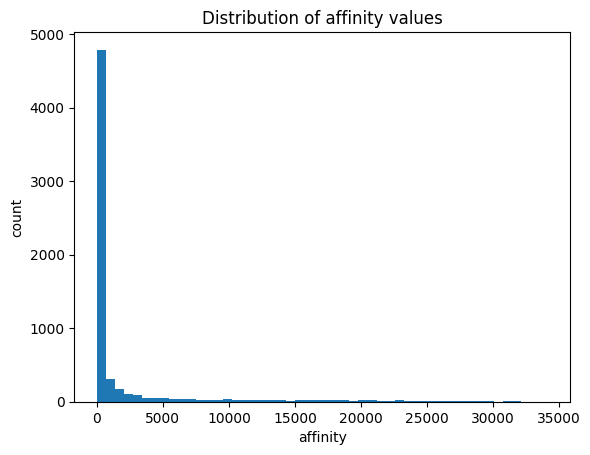

In [7]:
#affinity distribution

#mt
print(rollup["mt_affinity"].describe())

#histogram
import numpy as np 
import matplotlib.pyplot as plt
plt.hist(rollup["mt_affinity"].dropna().astype(float), bins=50)
plt.xlabel("affinity")
plt.ylabel("count")
plt.title("Distribution of affinity values")
plt.show()

count     6327.000000
mean      5234.284601
std       8776.276171
min          9.765469
25%         59.437739
50%        332.322980
75%       6436.771897
max      34099.792578
Name: wt_affinity, dtype: float64


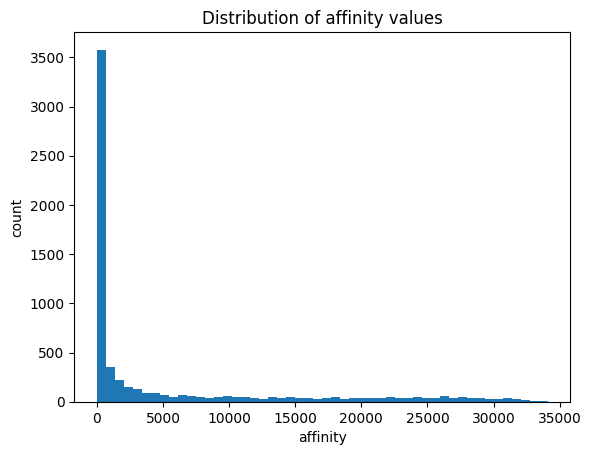

In [8]:
#affinity distribution of wt 
print(rollup["wt_affinity"].describe())

#histogram
plt.hist(rollup["wt_affinity"].dropna().astype(float), bins=50)
plt.xlabel("affinity")
plt.ylabel("count")
plt.title("Distribution of affinity values")
plt.show()

In [20]:
#save to file

rollup.to_csv("../../processed/final_predicted.csv", index=False)